# Real PV360 SPEN reconstruction, step by step

This notebook opens the traditional reconstruction pipeline on the actual scanner dataset:

`/home/data1/musong/workspace/python/spen_recons/spen_matlab/data/20240321_204022_lxj_spen_mouse_240321_1_1_1`

Unlike the synthetic notebook, real scanner data has no true phase map. That changes the question. Instead of asking *did we recover the true phase?*, we ask:

1. What did the scanner acquire?
2. What does the readout-FFT image look like before SPEN super-resolution?
3. What odd/even phase structure is estimated from the data itself?
4. How does the final `Image_SPEN` differ from the uncorrected traditional reconstruction?
5. What do the physical matrices `AFinal` and `InvA` tell us about the reconstruction operator?


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.set_grad_enabled(False)


def find_spenpy_repo(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in (start, *start.parents):
        if (path / 'pyproject.toml').exists() and (path / 'spenpy' / '__init__.py').exists():
            return path
        linked = path / 'spenpy'
        if (linked / 'pyproject.toml').exists() and (linked / 'spenpy' / '__init__.py').exists():
            return linked.resolve()
    fallback = Path('/home/data1/musong/workspace/python/spenpy')
    if fallback.exists():
        return fallback
    raise RuntimeError('Could not locate the spenpy repository root.')


SPENPY_REPO = find_spenpy_repo()
if str(SPENPY_REPO) not in sys.path:
    sys.path.insert(0, str(SPENPY_REPO))

from spenpy.bruker.image import read_bruker_2dseq
from spenpy.bruker.param import read_pv_param
from spenpy.bruker.raw import read_bruker_kspace_pv360_fid_multichannel
from spenpy.cli.pv360 import read_datalist
from spenpy.fft.transform import fft_kspace_to_xspace
from spenpy.recon.phase import apply_pv360_one_shot_phase_correction, even_odd_phase_fit
from spenpy.recon.spen_recon import (
    _build_cmplx_data,
    orient_pv360_spen_image,
    reconstruct_odd_segments,
)

print('SPENPy repo:', SPENPY_REPO)


SPENPy repo: /home/data1/musong/workspace/python/spenpy


## Parameters

`SPEN_INDEX` is 1-based inside `datalist.txt`. In this dataset, `SPEN_INDEX = 1` means scan ID 15. There are 43 SPEN scans in total, scan IDs 15 through 57.

In [2]:
DATA_DIR = Path('/home/data1/musong/workspace/python/spen_recons/spen_matlab/data/20240321_204022_lxj_spen_mouse_240321_1_1_1')
SPEN_INDEX = 1       # 1-based index among SPEN scans listed in datalist.txt
IMAGE_INDEX = 0      # receiver/image index before coil combination, usually 0..3 here

assert DATA_DIR.exists(), f'Missing scanner dataset: {DATA_DIR}'
print(DATA_DIR)


/home/data1/musong/workspace/python/spen_recons/spen_matlab/data/20240321_204022_lxj_spen_mouse_240321_1_1_1


## Plotting helpers

All complex images are displayed as magnitudes unless a panel is explicitly marked as phase. Phase is wrapped to `[-pi, pi]` so fitted phase fields are readable.

In [3]:
def to_numpy(x):
    if hasattr(x, 'detach'):
        return x.detach().cpu().resolve_conj().numpy()
    return np.asarray(x)


def first_2d(x):
    arr = np.asarray(to_numpy(x))
    arr = np.squeeze(arr)
    while arr.ndim > 2:
        arr = arr[..., arr.shape[-1] // 2]
    return arr


def abs_image(x):
    return np.abs(first_2d(x)).astype(np.float64)


def scale01(x, percentile=99.5):
    arr = abs_image(x)
    positive = arr[arr > 0]
    if positive.size == 0:
        return arr
    scale = np.percentile(positive, percentile)
    scale = scale if scale > 0 else float(arr.max())
    return np.clip(arr / max(scale, 1e-12), 0, 1)


def log_abs01(x):
    arr = abs_image(x)
    image = np.log1p(arr / max(float(arr.max()), 1e-12))
    return image / max(float(image.max()), 1e-12)


def wrap_phase(x):
    arr = first_2d(x)
    if np.iscomplexobj(arr):
        return np.angle(arr)
    return np.angle(np.exp(1j * arr.astype(np.float64)))


def phase_extent_rad(x):
    phase = wrap_phase(x)
    return float(np.percentile(phase, 1)), float(np.percentile(phase, 99))


def show_panels(panels, ncols=4, title=None, figsize=None):
    n = len(panels)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    if figsize is None:
        figsize = (4.2 * ncols, 3.9 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, panel in zip(axes, panels):
        panel_title, data, kind = panel if len(panel) == 3 else (*panel, 'mag')
        if kind == 'phase':
            image = wrap_phase(data)
            im = ax.imshow(image, cmap='twilight', vmin=-np.pi, vmax=np.pi)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_ticks([-np.pi, 0, np.pi])
            cbar.set_ticklabels(['-pi', '0', 'pi'])
        elif kind == 'logmag':
            im = ax.imshow(log_abs01(data), cmap='viridis', vmin=0, vmax=1)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        elif kind == 'mask':
            im = ax.imshow(first_2d(data).astype(float), cmap='gray', vmin=0, vmax=1)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        elif kind == 'error':
            image = first_2d(data).astype(np.float64)
            vmax = np.percentile(np.abs(image), 99.0)
            vmax = vmax if vmax > 0 else 1.0
            im = ax.imshow(image, cmap='coolwarm', vmin=-vmax, vmax=vmax)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            im = ax.imshow(scale01(data), cmap='gray', vmin=0, vmax=1)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(panel_title, fontsize=10)
        ax.set_axis_off()

    for ax in axes[n:]:
        ax.set_axis_off()
    if title:
        fig.suptitle(title, fontsize=13)
    plt.show()
    return fig


def read_structural_scan(scan_id):
    pdata_dir = DATA_DIR / str(scan_id) / 'pdata' / '1'
    image = np.squeeze(read_bruker_2dseq(str(pdata_dir)))
    if image.ndim >= 2:
        axes = list(range(image.ndim))
        axes[0], axes[1] = 1, 0
        image = np.transpose(image, axes)
    image = image / max(float(np.max(np.abs(image))), 1e-12)
    return image


## 1. Read the experiment layout

The MATLAB driver starts by reading `datalist.txt`: first RARE, then EPI, then all SPEN scans. We do the same here and show the structural scans for context.

RARE scan id: 4
EPI scan id : 6
SPEN scans  : 43 from 15 to 57
selected    : SPEN_INDEX = 1 , scan id = 15

PVM_Matrix        : [96, 96]
NSegments         : 1
PVM_Fov           : [16, 16]
SpenGyGaussStren  : 1.59291681020759
SpatEncDuration   : 11.0592
PVM_NEchoImages   : 1


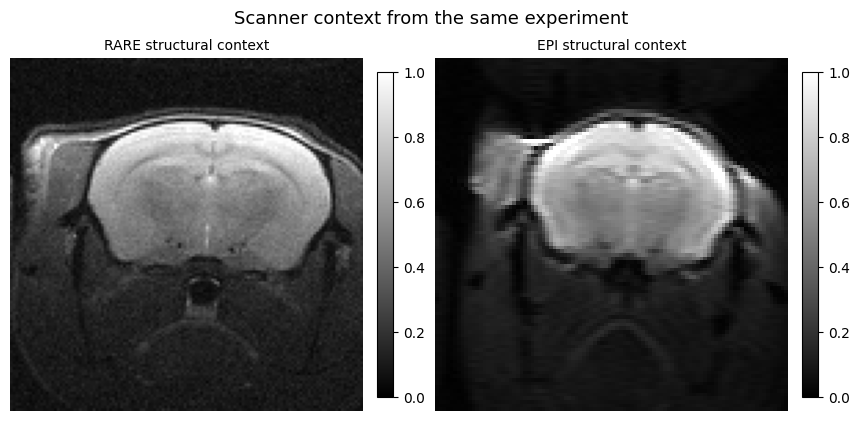

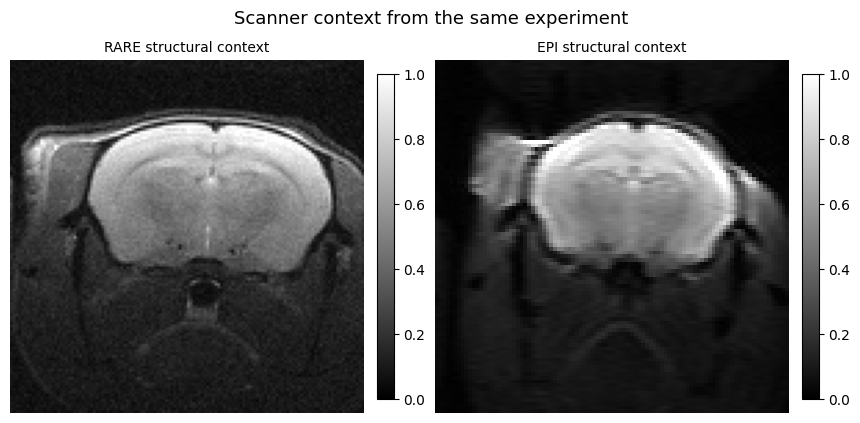

In [4]:
rare_id, epi_id, spen_ids = read_datalist(str(DATA_DIR))
scan_id = spen_ids[SPEN_INDEX - 1]
scan_dir = DATA_DIR / str(scan_id)

print('RARE scan id:', rare_id)
print('EPI scan id :', epi_id)
print('SPEN scans  :', len(spen_ids), 'from', spen_ids[0], 'to', spen_ids[-1])
print('selected    : SPEN_INDEX =', SPEN_INDEX, ', scan id =', scan_id)
print()
for key in ['PVM_Matrix', 'NSegments', 'PVM_Fov', 'SpenGyGaussStren', 'SpatEncDuration', 'PVM_NEchoImages']:
    print(f'{key:18s}:', read_pv_param(str(scan_dir), key))

rare = read_structural_scan(rare_id)
epi = read_structural_scan(epi_id)

show_panels(
    [
        ('RARE structural context', rare, 'mag'),
        ('EPI structural context', epi, 'mag'),
    ],
    ncols=2,
    title='Scanner context from the same experiment',
    figsize=(8.5, 4.2),
)


## 2. Reconstruct the selected SPEN scan

We run the traditional path twice:

- `process_with_pre_phase_corr=False`: readout FFT and SPEN adjoint without the one-shot odd/even phase correction.
- `process_with_pre_phase_corr=True`: the normal PV360 path, including phase correction before `InvA`.

The point is not to claim the uncorrected image is a valid output. It is a teaching panel that shows why phase correction is part of traditional reconstruction, not a cosmetic post-process.

raw k-space shape     : (96, 96, 1, 4, 1) complex128
regridded shape       : (96, 96, 1, 4, 1) complex64
Imag_origin shape     : (96, 96)
Imag_low shape        : (96, 96)
Image_SPEN shape      : (96, 96)
uncorrected-vs-corrected NRMSE: 0.2024


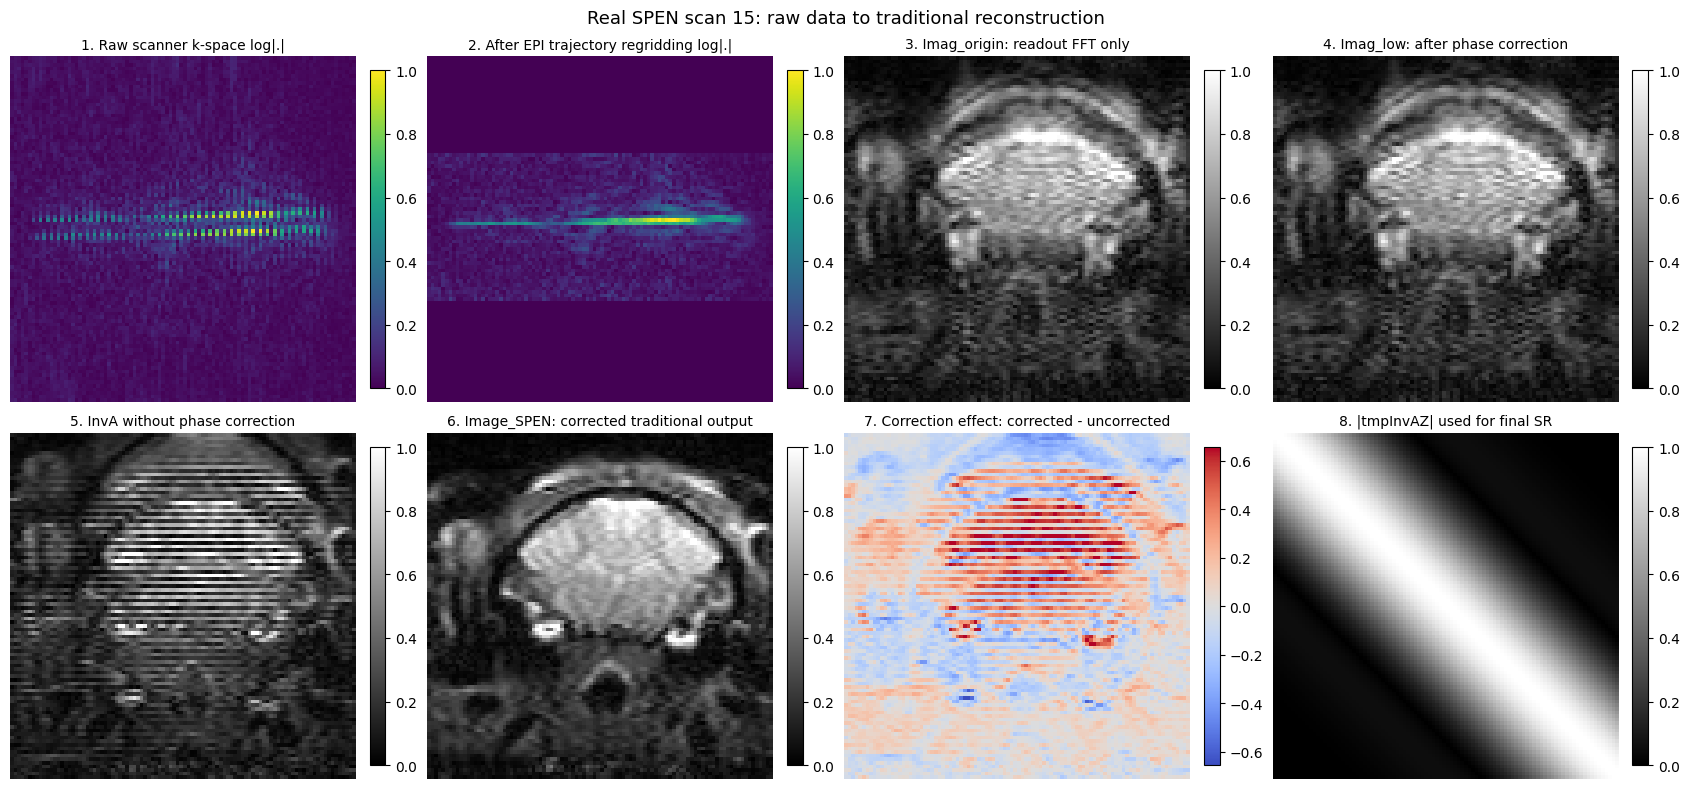

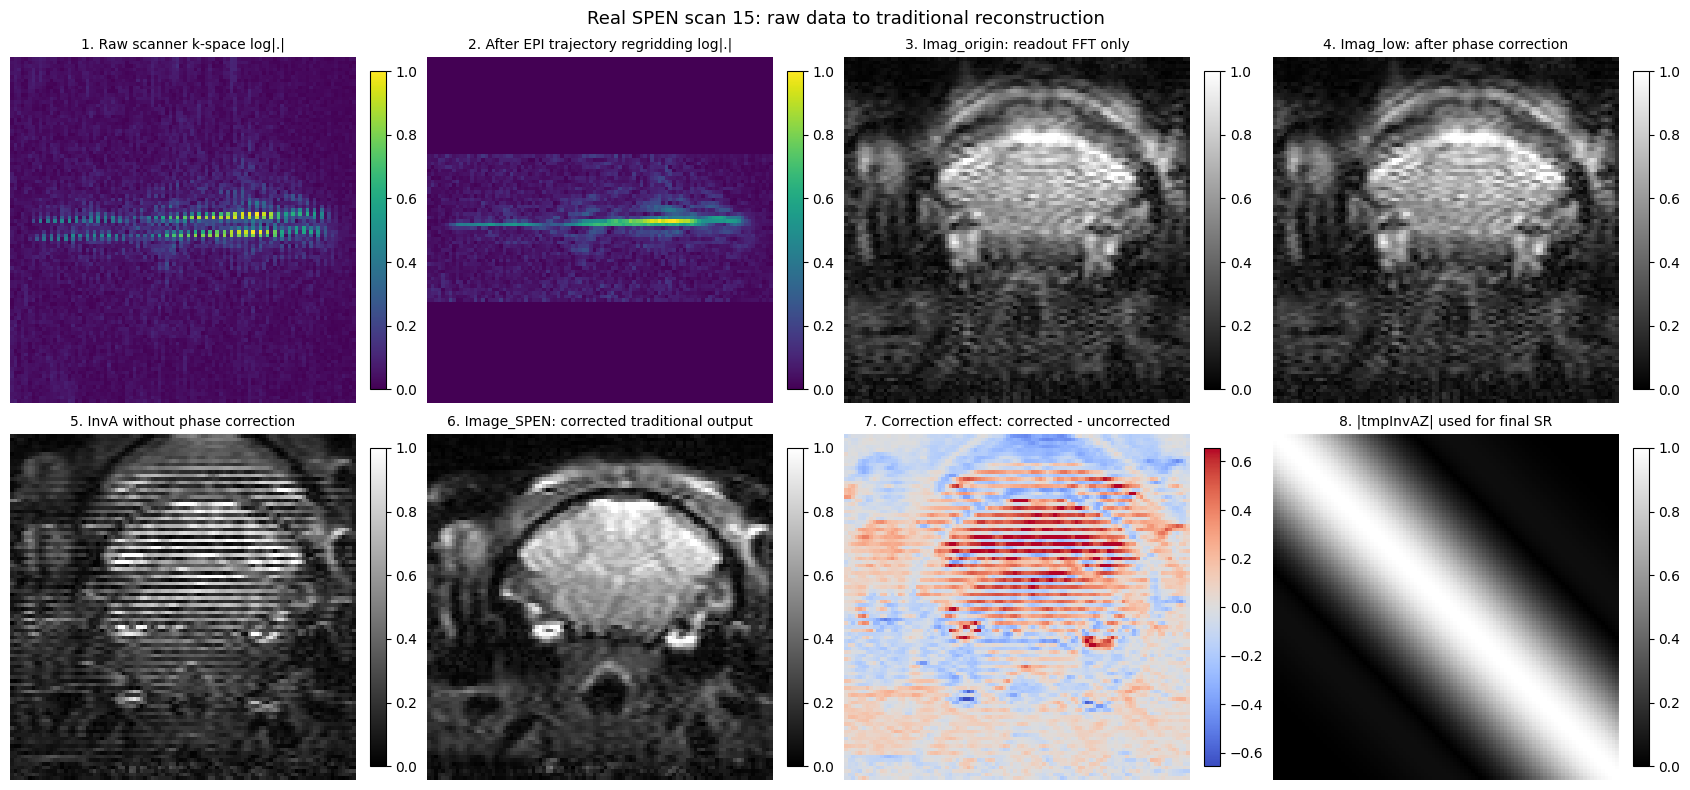

In [5]:
raw_kspace = read_bruker_kspace_pv360_fid_multichannel(str(scan_dir))

recon_uncorrected = reconstruct_odd_segments(
    str(scan_dir),
    process_with_pre_phase_corr=False,
)
recon_corrected = reconstruct_odd_segments(
    str(scan_dir),
    process_with_pre_phase_corr=True,
    smooth_motion_phase_between_shots=True,
)

image_uncorrected = orient_pv360_spen_image(recon_uncorrected.images)
image_spen = orient_pv360_spen_image(recon_corrected.images)
imag_origin = orient_pv360_spen_image(recon_corrected.imag_origin)
imag_low = orient_pv360_spen_image(recon_corrected.imag_low)
regrid_kspace = recon_corrected.kfield

delta = scale01(image_spen) - scale01(image_uncorrected)
nrmse_between = np.sqrt(np.mean(delta ** 2)) / max(float(np.ptp(scale01(image_spen))), 1e-12)

print('raw k-space shape     :', raw_kspace.shape, raw_kspace.dtype)
print('regridded shape       :', regrid_kspace.shape, regrid_kspace.dtype)
print('Imag_origin shape     :', imag_origin.shape)
print('Imag_low shape        :', imag_low.shape)
print('Image_SPEN shape      :', image_spen.shape)
print('uncorrected-vs-corrected NRMSE:', round(float(nrmse_between), 4))

show_panels(
    [
        ('1. Raw scanner k-space log|.|', raw_kspace, 'logmag'),
        ('2. After EPI trajectory regridding log|.|', regrid_kspace, 'logmag'),
        ('3. Imag_origin: readout FFT only', imag_origin, 'mag'),
        ('4. Imag_low: after phase correction', imag_low, 'mag'),
        ('5. InvA without phase correction', image_uncorrected, 'mag'),
        ('6. Image_SPEN: corrected traditional output', image_spen, 'mag'),
        ('7. Correction effect: corrected - uncorrected', delta, 'error'),
        ('8. |tmpInvAZ| used for final SR', recon_corrected.spen_az['tmpInvAZ'], 'mag'),
    ],
    ncols=4,
    title=f'Real SPEN scan {scan_id}: raw data to traditional reconstruction',
)


## 3. Estimate phase from the real odd/even data

There is no ground-truth phase map here. The phase map below is fitted from the scanner data itself by comparing odd and even SPEN rows after one-shot odd/even reconstruction. The mask shows which pixels were trusted during fitting.

The post-correction panels are a residual diagnostic: if strong structured phase remains, the phase-correction model is not explaining everything in the scan.

receiver/image frames before coil combine: 4
displayed IMAGE_INDEX: 0
pre-correction SmoothPhase 1-99% rad : (-2.991314789956392, 3.003255947557839)
post-correction SmoothPhase 1-99% rad: (-3.0584585471845145, 3.043233708275707)


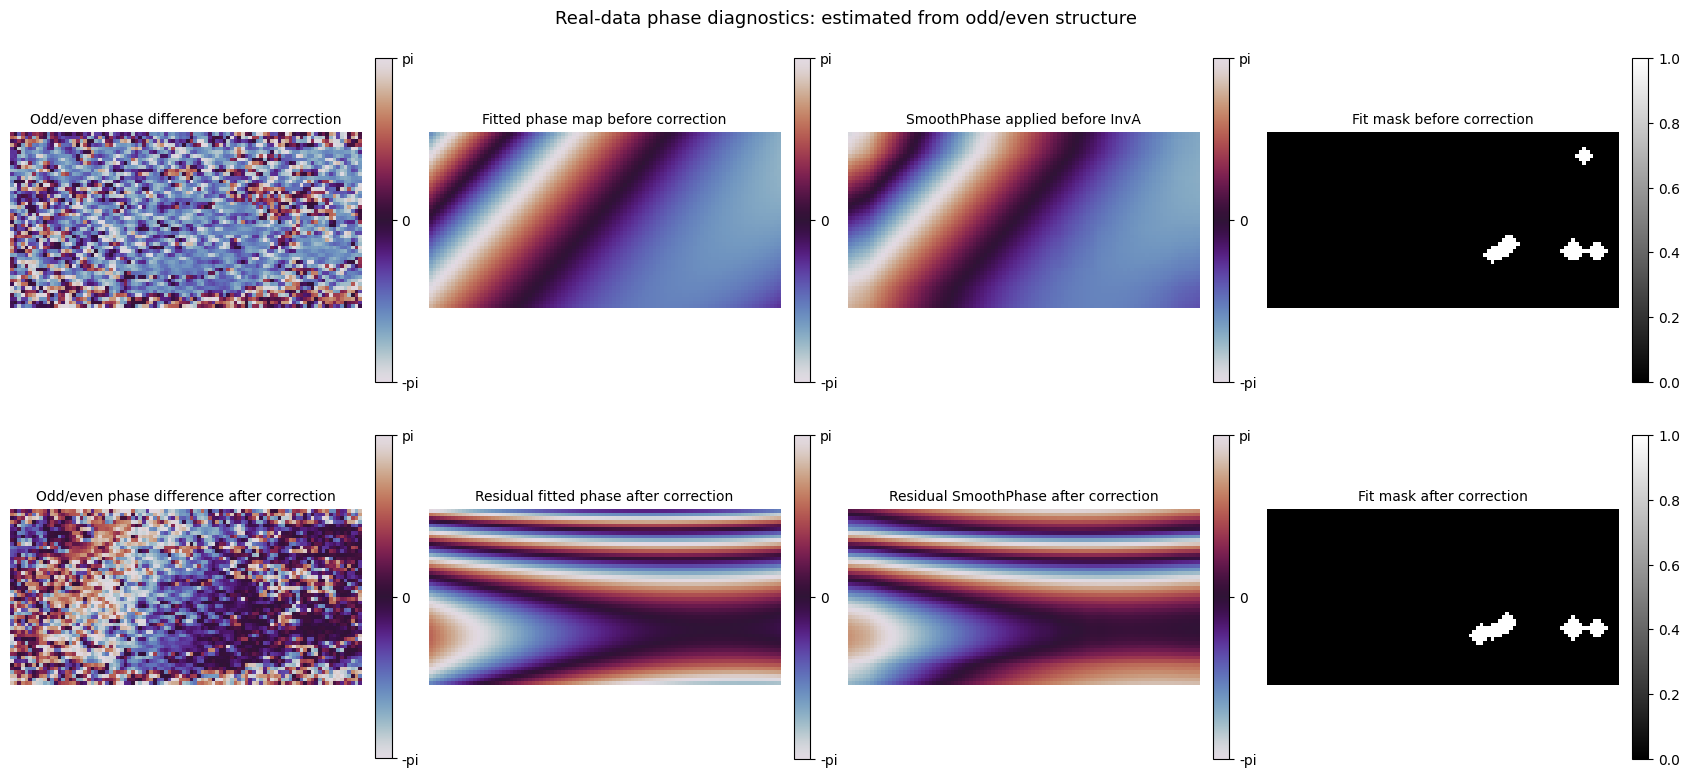

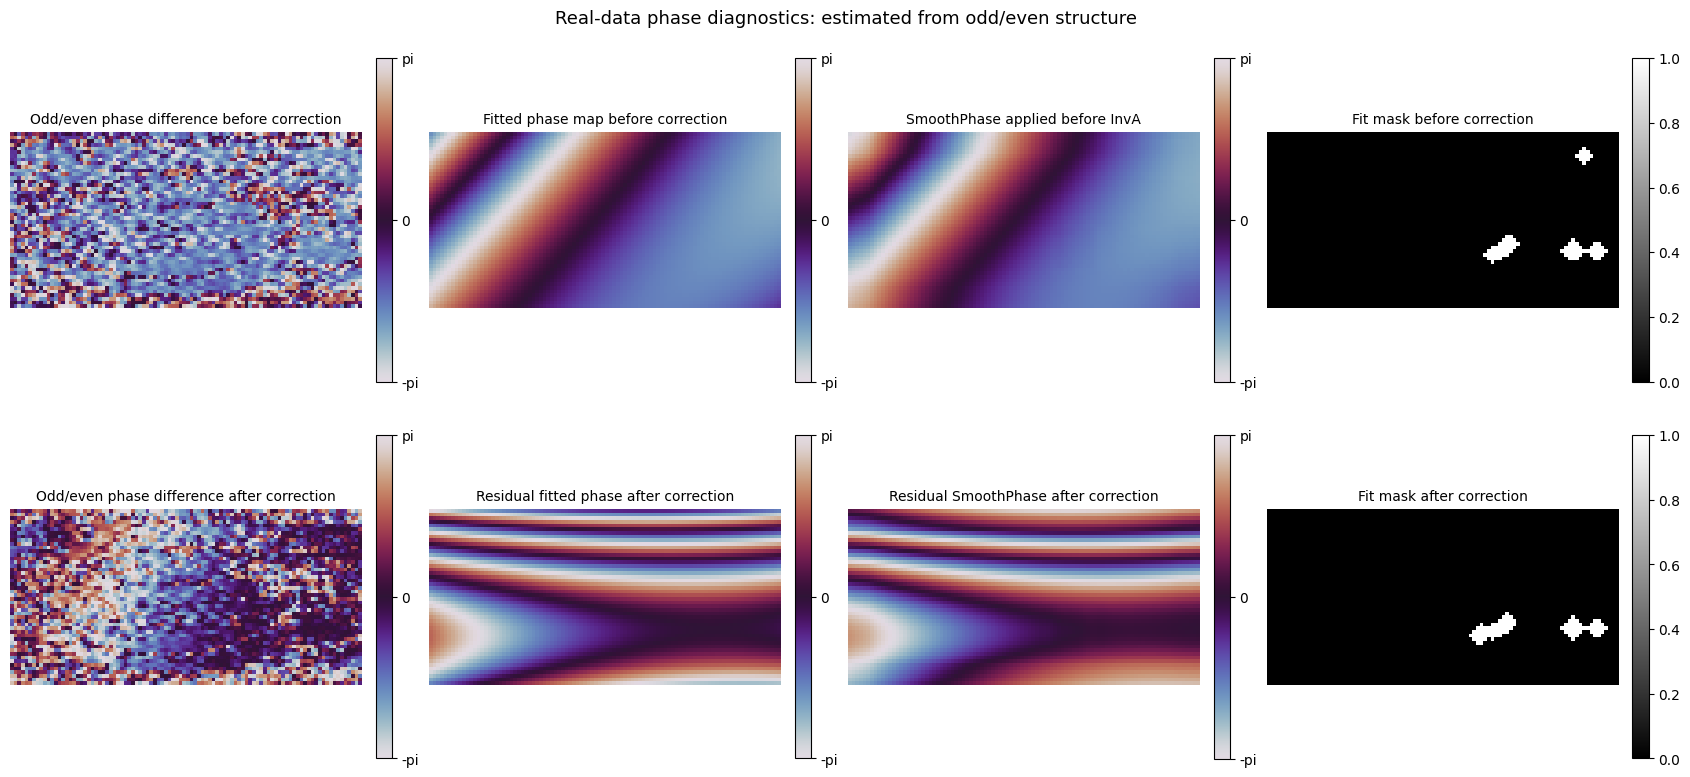

In [6]:
def fit_even_odd_phase(signal, odd_inv, even_inv, image_index=0):
    signal_np = to_numpy(signal).astype(np.complex128, copy=False)
    odd_inv_np = to_numpy(odd_inv).astype(np.complex128, copy=False)
    even_inv_np = to_numpy(even_inv).astype(np.complex128, copy=False)

    odd_sr = np.einsum('ab,brcn->arcn', odd_inv_np, signal_np[0::2, :, :, :])
    even_sr = np.einsum('ab,brcn->arcn', even_inv_np, signal_np[1::2, :, :, :])
    if image_index < 0 or image_index >= odd_sr.shape[-1]:
        raise ValueError(f'image_index must be in [0, {odd_sr.shape[-1] - 1}]')

    phase_difference = np.sum(even_sr * np.conj(odd_sr), axis=2)[:, :, image_index]
    fit = even_odd_phase_fit(
        odd_sr[:, :, 0, image_index],
        even_sr[:, :, 0, image_index],
        np.abs(odd_sr[:, :, 0, image_index]),
        np.abs(even_sr[:, :, 0, image_index]),
        coeffs_fit=[1, 1, 1, 1, 1, 1],
        morph_open=True,
        return_smooth_phase=True,
    )
    return fit, phase_difference


cmplx_data, _matrix_slice_num, slice_num2, array_num2, num_images = _build_cmplx_data(
    recon_uncorrected.kfield[:, :, :, :, 0]
)
roffted_before = fft_kspace_to_xspace(cmplx_data, dim=1)

inv_a = recon_corrected.spen_az['tmpInvAZ']
odd_inv = recon_corrected.spen_az['OneShotOddInvAZ']
even_inv = recon_corrected.spen_az['OneShotEvenInvAZ']

fit_before, phase_difference_before = fit_even_odd_phase(roffted_before, odd_inv, even_inv, IMAGE_INDEX)
roffted_after = apply_pv360_one_shot_phase_correction(
    roffted_before,
    inv_a,
    odd_inv,
    even_inv,
    optimize=True,
    smooth_motion_phase_between_shots=True,
)
fit_after, phase_difference_after = fit_even_odd_phase(roffted_after, odd_inv, even_inv, IMAGE_INDEX)

print('receiver/image frames before coil combine:', num_images)
print('displayed IMAGE_INDEX:', IMAGE_INDEX)
print('pre-correction SmoothPhase 1-99% rad :', phase_extent_rad(fit_before.smooth_phase))
print('post-correction SmoothPhase 1-99% rad:', phase_extent_rad(fit_after.smooth_phase))

show_panels(
    [
        ('Odd/even phase difference before correction', phase_difference_before, 'phase'),
        ('Fitted phase map before correction', fit_before.phase_map, 'phase'),
        ('SmoothPhase applied before InvA', fit_before.smooth_phase, 'phase'),
        ('Fit mask before correction', fit_before.mask, 'mask'),
        ('Odd/even phase difference after correction', phase_difference_after, 'phase'),
        ('Residual fitted phase after correction', fit_after.phase_map, 'phase'),
        ('Residual SmoothPhase after correction', fit_after.smooth_phase, 'phase'),
        ('Fit mask after correction', fit_after.mask, 'mask'),
    ],
    ncols=4,
    title='Real-data phase diagnostics: estimated from odd/even structure',
)


## 4. Inspect the physical reconstruction matrices

The final image is not produced by a neural network in this notebook. It is produced by a scanner-derived SPEN encoding model and its weighted adjoint. Visualizing these matrices makes the reconstruction less mysterious.

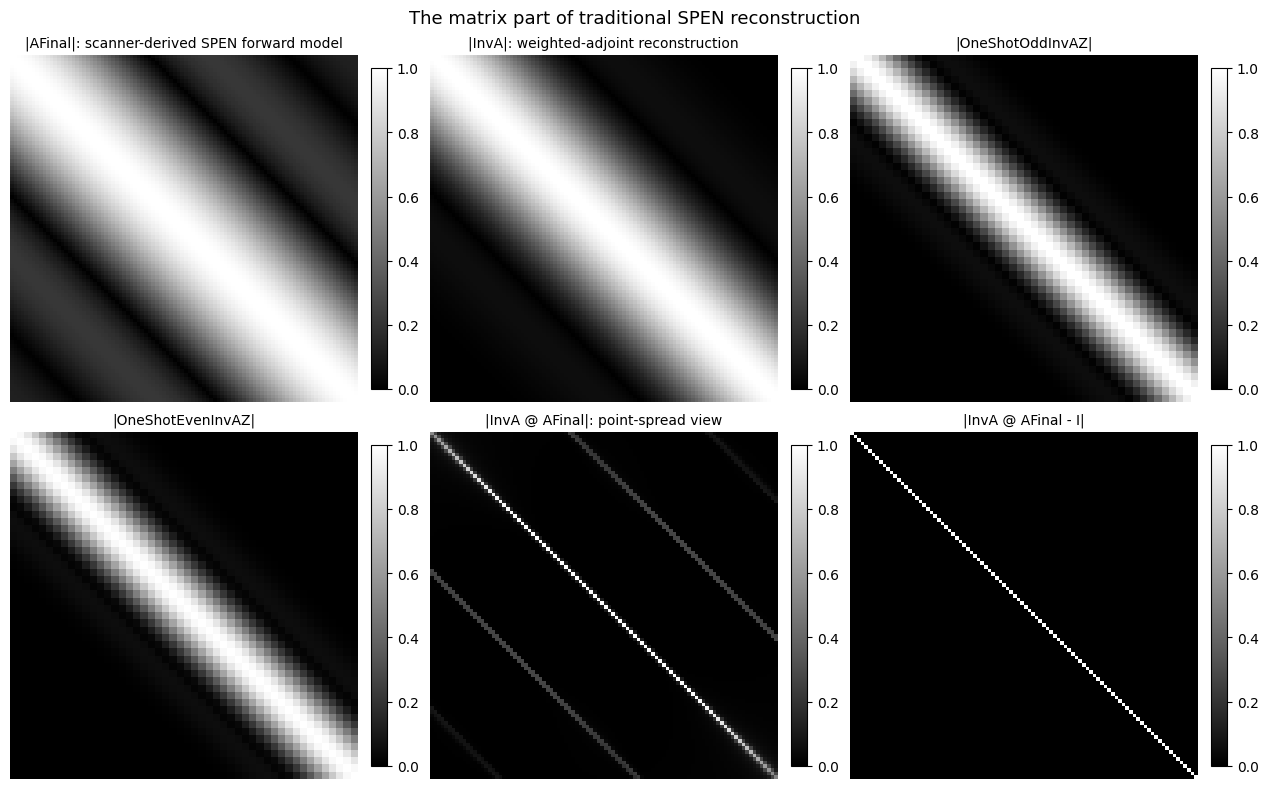

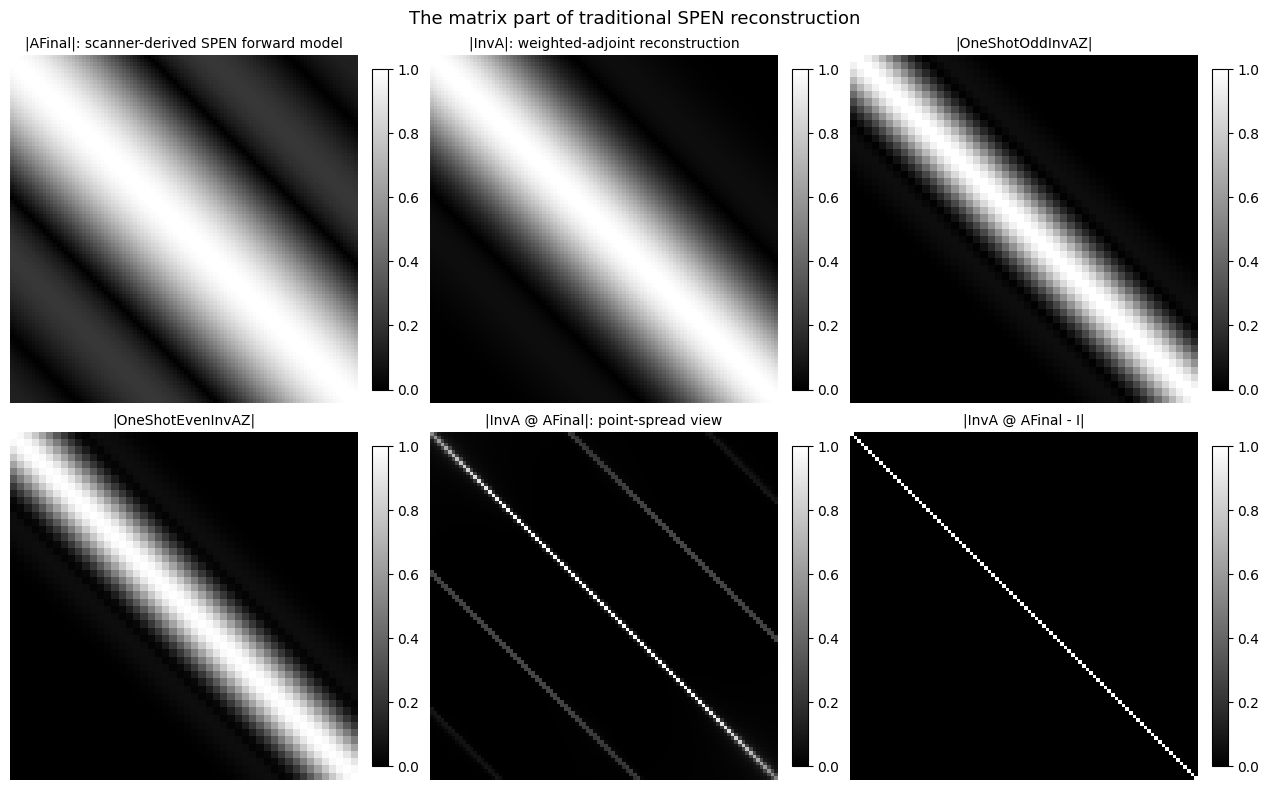

In [7]:
AFinal = recon_corrected.spen_az['tmpAFinal']
InvA = recon_corrected.spen_az['tmpInvAZ']
system_response = torch.matmul(InvA, AFinal)
identity_error = torch.abs(system_response - torch.eye(system_response.shape[0], dtype=system_response.dtype))

show_panels(
    [
        ('|AFinal|: scanner-derived SPEN forward model', AFinal, 'mag'),
        ('|InvA|: weighted-adjoint reconstruction', InvA, 'mag'),
        ('|OneShotOddInvAZ|', odd_inv, 'mag'),
        ('|OneShotEvenInvAZ|', even_inv, 'mag'),
        ('|InvA @ AFinal|: point-spread view', system_response, 'mag'),
        ('|InvA @ AFinal - I|', identity_error, 'mag'),
    ],
    ncols=3,
    title='The matrix part of traditional SPEN reconstruction',
)


## 5. A compact storyboard for this real scan

Set `SAVE_SUMMARY = True` to save this figure under `spenpy/demo/outputs/`.

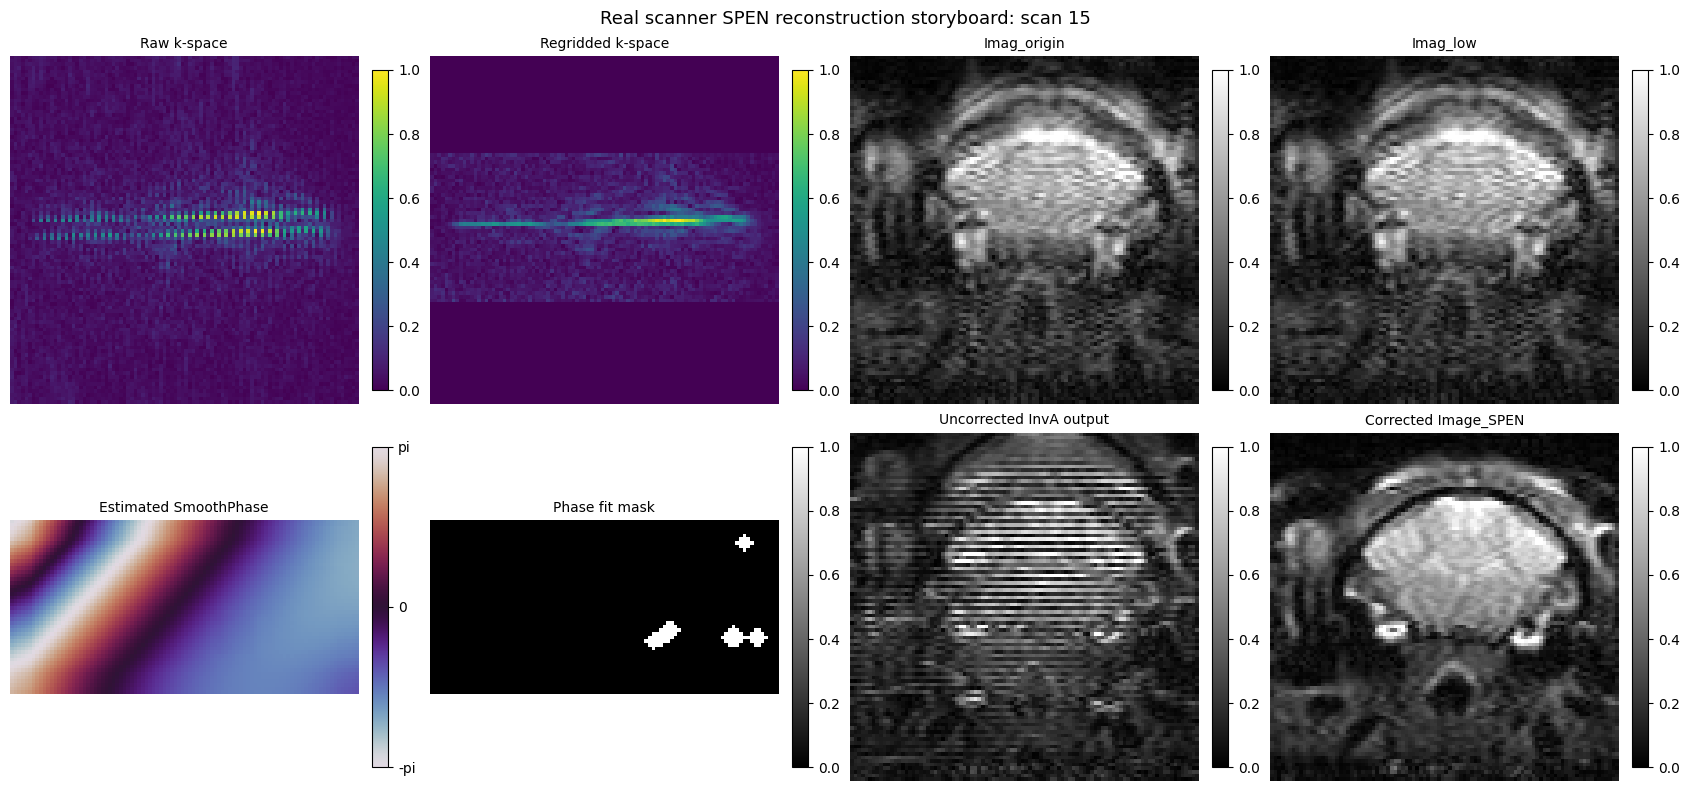

In [8]:
SAVE_SUMMARY = False
summary_dir = SPENPY_REPO / 'demo/outputs'
summary_path = summary_dir / f'real_scanner_spen_{SPEN_INDEX:03d}_storyboard.png'

fig = show_panels(
    [
        ('Raw k-space', raw_kspace, 'logmag'),
        ('Regridded k-space', regrid_kspace, 'logmag'),
        ('Imag_origin', imag_origin, 'mag'),
        ('Imag_low', imag_low, 'mag'),
        ('Estimated SmoothPhase', fit_before.smooth_phase, 'phase'),
        ('Phase fit mask', fit_before.mask, 'mask'),
        ('Uncorrected InvA output', image_uncorrected, 'mag'),
        ('Corrected Image_SPEN', image_spen, 'mag'),
    ],
    ncols=4,
    title=f'Real scanner SPEN reconstruction storyboard: scan {scan_id}',
)

if SAVE_SUMMARY:
    summary_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(summary_path, dpi=180)
    print('saved:', summary_path)


## 6. Optional: make a small slice gallery across the SPEN scan list

This is off by default because it reconstructs several scanner scans. Turn it on when you want to see how the traditional reconstruction behaves across the 43 SPEN entries in `datalist.txt`.

In [9]:
RUN_GALLERY = False
GALLERY_INDICES = [1, 8, 15, 22, 29, 36, 43]

if RUN_GALLERY:
    gallery = []
    for idx in GALLERY_INDICES:
        sid = spen_ids[idx - 1]
        recon = reconstruct_odd_segments(
            str(DATA_DIR / str(sid)),
            process_with_pre_phase_corr=True,
            smooth_motion_phase_between_shots=True,
        )
        gallery.append((f'SPEN {idx} / scan {sid}', orient_pv360_spen_image(recon.images), 'mag'))
    show_panels(gallery, ncols=len(gallery), title='Traditional Image_SPEN gallery across the real scan list')
else:
    print('RUN_GALLERY is False. Set it to True to reconstruct a small gallery across the scan list.')


RUN_GALLERY is False. Set it to True to reconstruct a small gallery across the scan list.


## Takeaways

- The real PV360 reconstruction starts from raw complex k-space, not an already-clean image.
- `Imag_origin`, `Imag_low`, and `Image_SPEN` are different stages, not three versions of the same final output.
- Real scanner data cannot show true phase, so phase diagnostics must be judged through fitted phase maps, masks, residual phase, and image-space behavior.
- Traditional reconstruction is interpretable: every major correction has a visible intermediate image or matrix.